In [ ]:
print("init")

init


In [2]:
import os
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio
from PIL import Image
import cv2

from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
import re

In [3]:
DEVICE = "mps"
MODEL_NAME = "Qwen/Qwen3-VL-2B-Instruct" 
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
dtype = torch.float32


In [4]:
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    trust_remote_code=True,
)
model.to(DEVICE)
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1024)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
 

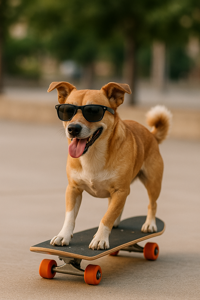

In [5]:
IMAGE_PATH = "img2.png" 
raw_image = Image.open(IMAGE_PATH).convert("RGB")
raw_image = raw_image.resize((200,300))
raw_image

In [7]:
messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": raw_image},
                {"type": "text", "text": "Describe the sequence of events briefly at most 10 words."},
            ],
        }
    ]
inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )
inputs = inputs.to(DEVICE)
inputs

{'input_ids': tensor([[151644,    872,    198, 151652, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151653,  74785,    279,   8500,    315,   4357,  26753,
            518,   1429,    220,     16,     15,   4244,     13, 151645,    198,
         151644,  77091,    198]], device='mps:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1

image_grid_thw is Qwen3-VL’s internal metadata tensor that describes how the image is split into visual tokens.

It tells the model:

T = number of “temporal” frames (almost always 1 for images)
H = number of grid rows (after the visual encoder)
W = number of grid columns

In [ ]:
print(inputs["input_ids"].shape,inputs["pixel_values"].shape)

torch.Size([1, 93]) torch.Size([280, 1536])


inputs["pixel_values"] is actually image_tensor_emb

Not raw pixels.

📦 So what does [280,1536] actually mean?
280 → Number of image patch embeddings

After splitting and spatial merging.

1536 → Embedding dimension

The size of Qwen3-VL-2B’s hidden space.

So this tensor represents:

The set of visual patch tokens Qwen will feed into the LLM.

It is not RGB pixels anymore.

In [13]:
# inputs["input_ids"][:, -1:]

In [20]:
# generate_caption_and_hidden_states_onepass
# manually decode autoregressively

 # Hidden states we will collect
collected_hidden = []
# KV cache
past_key_values = None
# We will autoregressively decode
full_ids = inputs["input_ids"].clone()
max_new_tokens = 40

with torch.no_grad():
    out = model(
        input_ids=inputs["input_ids"],      # last token only
        attention_mask=inputs["attention_mask"],
        pixel_values=inputs["pixel_values"],
        image_grid_thw=inputs["image_grid_thw"],
        use_cache=True,
        past_key_values=past_key_values,
        output_hidden_states=True,
    )
past_key_values = out.past_key_values

# Capture hidden state of the last prompt token
# hidden_states = [out.hidden_states[layer_index][0, -1, :].unsqueeze(0)]
# for _ in range(max_new_tokens):

print(len(out.hidden_states),out.hidden_states[0].shape,out.hidden_states[10].shape)
out.logits.shape

29 torch.Size([1, 93, 2048]) torch.Size([1, 93, 2048])


torch.Size([1, 93, 151936])